17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.6046 - loss: 0.6511 - val_accuracy: 0.7790 - val_loss: 0.4838
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.7836 - loss: 0.4717 - val_accuracy: 0.7922 - val_loss: 0.4490
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.7983 - loss: 0.4354 - val_accuracy: 0.7956 - val_loss: 0.4361
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.8072 - loss: 0.4162 - val_accuracy: 0.8024 - val_loss: 0.4259
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8120 - loss: 0.4131 - val_accuracy: 0.8060 - val_loss: 0.4208
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.8155 - loss: 0.3987 - val_accuracy: 0.8032 - val_loss: 0.4260
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8181 - loss: 0.3947 - val_accuracy: 0.8046 - val_loss: 0.4260
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.8232 - loss: 0

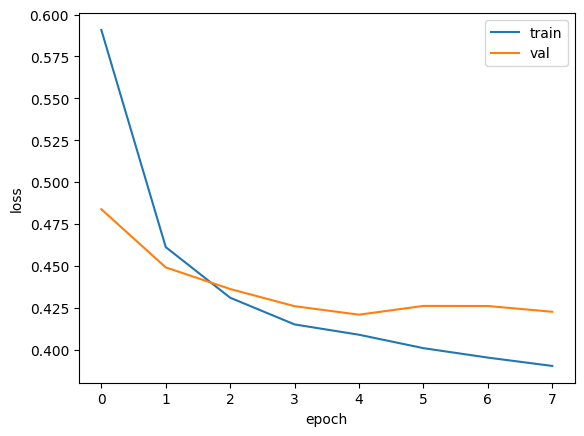

In [2]:
from tensorflow.keras.datasets import imdb
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)
# 샘플 길이 100개, 부족하면 패딩 추가
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)
# LSTM셀을 이용한 순환층
import keras
model_lstm = keras.Sequential()
model_lstm.add(keras.layers.Input(shape=(100,)))
model_lstm.add(keras.layers.Embedding(500, 16))
model_lstm.add(keras.layers.LSTM(8))
model_lstm.add(keras.layers.Dense(1, activation='sigmoid'))
model_lstm.summary() # 작은 셀이 4개 있으므로 200->800
# 훈련
model_lstm.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_lstm.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])
# 훈련 손실과 검증 손실 그래프로 출력
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.5884 - loss: 0.6680 - val_accuracy: 0.7638 - val_loss: 0.5186
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.7750 - loss: 0.4981 - val_accuracy: 0.7182 - val_loss: 0.5607
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.7752 - loss: 0.4721 - val_accuracy: 0.7984 - val_loss: 0.4389
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.7987 - loss: 0.4397 - val_accuracy: 0.7970 - val_loss: 0.4357
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.7979 - loss: 0.4313 - val_accuracy: 0.8004 - val_loss: 0.4293
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8055 - loss: 0.4181 - val_accuracy: 0.8014 - val_loss: 0.4266
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8130 - loss: 0.4148 - val_accuracy: 0.8038 - val_loss: 0.4257
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.8056 - loss: 0

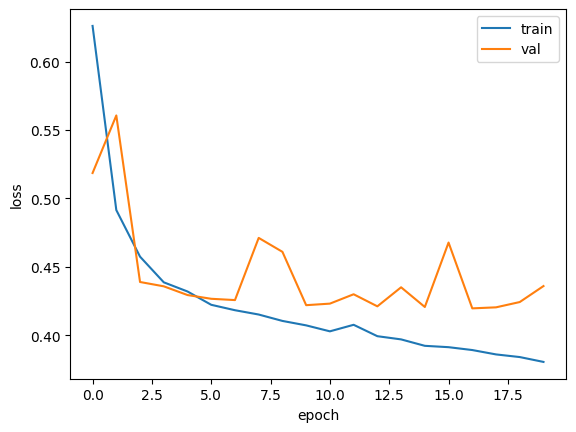

In [3]:
# 순환층에 드롭아웃 적용하기

# 20%의 입력을 드롭아웃
model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Input(shape=(100,)))
model_dropout.add(keras.layers.Embedding(500, 16))
model_dropout.add(keras.layers.LSTM(8, dropout=0.3))
model_dropout.add(keras.layers.Dense(1, activation='sigmoid'))
# 훈련
model_dropout.compile(optimizer='adam', loss='binary_crossentropy',
               metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-dropout-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_dropout.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])
# 훈련손실과 검증 손실 그래프 출력
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.5963 - loss: 0.6484 - val_accuracy: 0.7746 - val_loss: 0.4901
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7769 - loss: 0.4873 - val_accuracy: 0.7692 - val_loss: 0.4835
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.7843 - loss: 0.4656 - val_accuracy: 0.7990 - val_loss: 0.4405
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.8033 - loss: 0.4313 - val_accuracy: 0.7828 - val_loss: 0.4618
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.8043 - loss: 0.4268 - val_accuracy: 0.8018 - val_loss: 0.4286
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.8032 - loss: 0.4258 - val_accuracy: 0.7944 - val_loss: 0.4366
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.8083 - loss: 0.4183 - val_accuracy: 0.8072 - val_loss: 0.4223
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 71ms/step - accuracy: 0.8135 - loss: 0

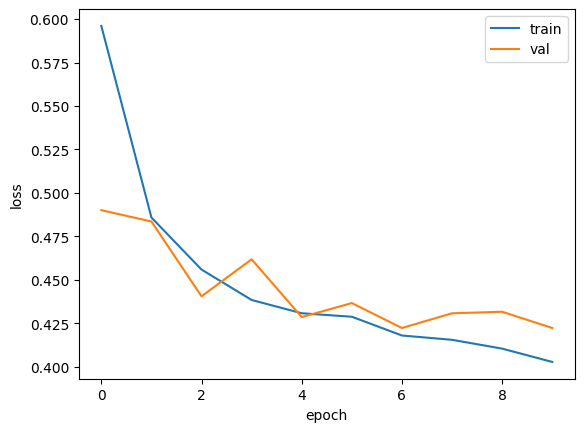

In [4]:
# 2개의 층을 연결하기

# 순환층에서 모든 타임스텝의 은닉 상태를 출력하려면
# 마지막을 제외한 모든 순환층에 return_sequences=true로 지정하면 됨.
model_2lstm = keras.Sequential()
model_2lstm.add(keras.layers.Input(shape=(100,)))
model_2lstm.add(keras.layers.Embedding(500, 16))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2, return_sequences=True))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2))
model_2lstm.add(keras.layers.Dense(1, activation='sigmoid'))
model_2lstm.summary()
# 훈련
model_2lstm.compile(optimizer='adam', loss='binary_crossentropy',
               metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-2rnn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_2lstm.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])
# 손실 그래프 출력
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5152 - loss: 0.6927

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.5153 - loss: 0.6927 - val_accuracy: 0.5510 - val_loss: 0.6916
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5535 - loss: 0.6910

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.5535 - loss: 0.6910 - val_accuracy: 0.5740 - val_loss: 0.6895
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5852 - loss: 0.6883

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8106 - loss: 0.4235 - val_accuracy: 0.7930 - val_loss: 0.4460
Epoch 31/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8142 - loss: 0.4212

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8142 - loss: 0.4212 - val_accuracy: 0.7932 - val_loss: 0.4454
Epoch 32/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8093 - loss: 0.4223 - val_accuracy: 0.7942 - val_loss: 0.4494
Epoch 33/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8145 - loss: 0.4189

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8145 - loss: 0.4189 - val_accuracy: 0.7924 - val_loss: 0.4450
Epoch 34/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8069 - loss: 0.4251 - val_accuracy: 0.7830 - val_loss: 0.4637
Epoch 35/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.8086 - loss: 0.4239 - val_accuracy: 0.7938 - val_loss: 0.4529
Epoch 36/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8172 - loss: 0.4143

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8172 - loss: 0.4143 - val_accuracy: 0.7918 - val_loss: 0.4432
Epoch 37/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8161 - loss: 0.4142

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.8161 - loss: 0.4142 - val_accuracy: 0.7936 - val_loss: 0.4426
Epoch 38/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8134 - loss: 0.4164 - val_accuracy: 0.7932 - val_loss: 0.4483
Epoch 39/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8149 - loss: 0.4110 - val_accuracy: 0.7922 - val_loss: 0.4433
Epoch 40/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8198 - loss: 0.4127 - val_accuracy: 0.7922 - val_loss: 0.4471


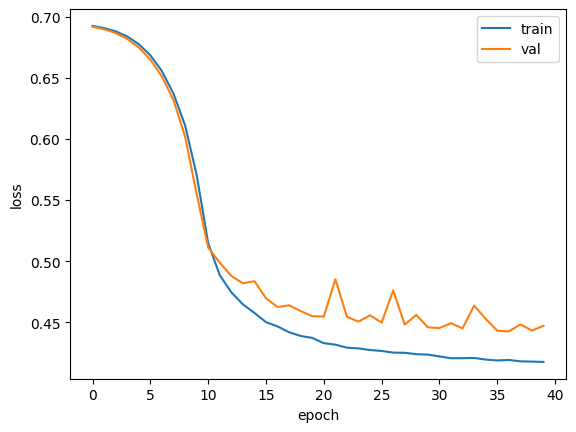

In [5]:
# GPU 구조
model4=keras.Sequential()
model4.add(keras.layers.Embedding(500,16,input_length=100))
model4.add(keras.layers.GRU(8))
model4.add(keras.layers.Dense(1,activation='sigmoid'))
# 훈련
rmsprop=keras.optimizers.RMSprop(learning_rate=1e-4)
model4.compile(optimizer=rmsprop, loss='binary_crossentropy',
                metrics=['accuracy'])
checkpoint_cb=keras.callbacks.ModelCheckpoint('best-gru-model.h5',
                                              save_best_only=True)
early_stopping_cb=keras.callbacks.EarlyStopping(patience=3,
                                                restore_best_weights=True)
history=model4.fit(train_seq, train_target, epochs=100, batch_size=64,
                   validation_data=(val_seq, val_target),
                   callbacks=[checkpoint_cb, early_stopping_cb])
# 손실 그래프
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()